# 08 — Neural Architecture Search (NAS) with Optuna

## Why Optuna Instead of karpathy/autoresearch?

**karpathy/autoresearch** is designed for GPT-style LLM training (fixed `train.py`, bpb metric). 
It doesn't support:
- Medical multimodal architectures
- Regression targets (dB/year, %/year)
- Variable-length time-series with masking

**Optuna** (Bayesian optimization) is the right tool here:
- Searches architecture + hyperparameter space simultaneously
- Pruning: kills bad trials early (3× faster)
- Parallel trials: run across GPU/CPU workers
- Tracks all runs in a SQLite DB for analysis

## Search Space
- Backbone: `convnext_small` | `efficientnet_b3`
- Temporal: `bilstm` | `transformer`
- Hidden dims, dropout, learning rate, batch size
- Loss: `weighted_dual` | `nll`

In [1]:
import sys
sys.path.insert(0, "..")

import optuna
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path

from src.models.backbones import ConvNeXtBackbone, EfficientNetBackbone, VisualFieldEncoder
from src.models.temporal import BidirectionalLSTM, TemporalTransformer
from src.models.fusion import AttentionFusion, ClinicalEmbedder
from src.models.heads import ProgressionHead, GLAMModel
from src.losses.progression import WeightedDualRegressionLoss, NegativeLogLikelihoodLoss
from src.utils.metrics import compute_all_metrics

optuna.logging.set_verbosity(optuna.logging.WARNING)  # Less verbose

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Path("../reports").mkdir(parents=True, exist_ok=True)
Path("../configs/model").mkdir(parents=True, exist_ok=True)
DB_PATH = Path("../reports/nas_study.db").resolve()

N_TRIALS = 20   # Increase to 100+ for serious NAS
N_EPOCHS_PER_TRIAL = 10   # Short training per trial; increase for final eval

Device: cpu


## 1. Synthetic Data for NAS

In [2]:
def make_synthetic_batch(n=400, max_visits=10, n_vf=54, n_clin=12, seed=42):
    rng = np.random.default_rng(seed)
    rates = rng.choice([-0.2, -0.5, -1.0, -2.0, -3.0], n, p=[0.3, 0.25, 0.2, 0.15, 0.1])
    
    images   = torch.randn(n, 3, 224, 224, dtype=torch.float32)
    vf       = torch.randn(n, max_visits, n_vf, dtype=torch.float32)
    clinical = torch.randn(n, n_clin, dtype=torch.float32)
    lengths  = torch.randint(3, max_visits+1, (n,), dtype=torch.long)
    md_rate  = torch.tensor(rates + rng.normal(0, 0.1, n), dtype=torch.float32)
    vfi_rate = torch.tensor(rates * 2.5 + rng.normal(0, 0.3, n), dtype=torch.float32)
    
    return images, vf, clinical, lengths, md_rate, vfi_rate

imgs, vf, clin, lens, md_rate, vfi_rate = make_synthetic_batch(n=400)
n_train = 280

train_ds = TensorDataset(imgs[:n_train], vf[:n_train], clin[:n_train],
                          lens[:n_train], md_rate[:n_train], vfi_rate[:n_train])
val_ds   = TensorDataset(imgs[n_train:], vf[n_train:], clin[n_train:],
                          lens[n_train:], md_rate[n_train:], vfi_rate[n_train:])

print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Train: 280 | Val: 120


## 2. Trial Builder — Build Model from Hyperparams

In [3]:
def build_model_from_trial(trial: optuna.Trial) -> GLAMModel:
    """Build a GLAMModel from Optuna trial hyperparameters."""
    
    # --- Backbone ---
    backbone_type = trial.suggest_categorical("backbone", ["convnext", "efficientnet"])
    if backbone_type == "convnext":
        backbone = ConvNeXtBackbone(pretrained=False)
        struct_dim = 768
    else:
        backbone = EfficientNetBackbone(pretrained=False)
        struct_dim = 1536
    
    # --- VF Encoder ---
    vf_hidden = trial.suggest_categorical("vf_hidden_dim", [128, 256])
    vf_encoder = VisualFieldEncoder(n_points=54, hidden_dim=vf_hidden)
    
    # --- Temporal Model ---
    temporal_type = trial.suggest_categorical("temporal", ["bilstm", "transformer"])
    temporal_hidden = trial.suggest_categorical("temporal_hidden", [128, 256])
    temporal_dropout = trial.suggest_float("temporal_dropout", 0.1, 0.4, step=0.1)
    
    if temporal_type == "bilstm":
        n_lstm_layers = trial.suggest_int("lstm_layers", 1, 3)
        temporal_model = BidirectionalLSTM(
            input_dim=vf_hidden, hidden_dim=temporal_hidden,
            num_layers=n_lstm_layers, dropout=temporal_dropout
        )
        func_dim = temporal_hidden * 2
    else:
        n_tf_layers = trial.suggest_int("tf_layers", 2, 4)
        n_heads = trial.suggest_categorical("tf_heads", [4, 8])
        temporal_model = TemporalTransformer(
            input_dim=vf_hidden, d_model=temporal_hidden,
            nhead=n_heads, num_layers=n_tf_layers, dropout=temporal_dropout
        )
        func_dim = temporal_hidden
    
    # --- Clinical Embedder ---
    clin_embed_dim = trial.suggest_categorical("clin_embed_dim", [64, 128])
    clinical_embedder = ClinicalEmbedder(n_clinical_features=12, embed_dim=clin_embed_dim)
    
    # --- Fusion ---
    fused_dim = trial.suggest_categorical("fused_dim", [256, 512])
    fusion_dropout = trial.suggest_float("fusion_dropout", 0.1, 0.3, step=0.1)
    fusion = AttentionFusion(
        structural_dim=struct_dim, functional_dim=func_dim,
        clinical_dim=clin_embed_dim, fused_dim=fused_dim, dropout=fusion_dropout
    )
    
    # --- Prediction Head ---
    head_dropout = trial.suggest_float("head_dropout", 0.1, 0.4, step=0.1)
    head = ProgressionHead(input_dim=fused_dim, dropout=head_dropout)
    
    return GLAMModel(backbone, vf_encoder, temporal_model, fusion, clinical_embedder, head)


def trial_hparams(trial: optuna.Trial) -> dict:
    """Training hyperparameters for a trial."""
    return {
        "lr":         trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "wd":         trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32]),
        "loss_type":  trial.suggest_categorical("loss_type", ["weighted", "nll"]),
    }

## 3. Objective Function

In [4]:
def evaluate_model(model, val_loader, criterion) -> float:
    model.eval()
    all_md_pred, all_md_true, all_vfi_pred, all_vfi_true = [], [], [], []
    
    with torch.no_grad():
        for batch in val_loader:
            imgs_b, vf_b, clin_b, lens_b, md_b, vfi_b = [b.to(device) for b in batch]
            preds = model(imgs_b, vf_b, clin_b, vf_lengths=lens_b)
            all_md_pred.append(preds["md_pred"].squeeze(1).cpu())
            all_md_true.append(md_b.cpu())
            all_vfi_pred.append(preds["vfi_pred"].squeeze(1).cpu())
            all_vfi_true.append(vfi_b.cpu())
    
    md_pred = torch.cat(all_md_pred).numpy()
    md_true = torch.cat(all_md_true).numpy()
    vfi_pred = torch.cat(all_vfi_pred).numpy()
    vfi_true = torch.cat(all_vfi_true).numpy()
    
    metrics = compute_all_metrics(md_pred, md_true, vfi_pred, vfi_true)
    # Optimize: MD MAE + 0.5 * VFI MAE (weighted sum — lower is better)
    return metrics["md_mae"] + 0.5 * metrics["vfi_mae"]


def objective(trial: optuna.Trial) -> float:
    hparams = trial_hparams(trial)
    
    try:
        model = build_model_from_trial(trial).to(device)
        
        if hparams["loss_type"] == "nll":
            criterion = NegativeLogLikelihoodLoss()
        else:
            criterion = WeightedDualRegressionLoss()
        
        optimizer = torch.optim.AdamW(
            model.parameters(), lr=hparams["lr"], weight_decay=hparams["wd"]
        )
        
        train_loader = DataLoader(train_ds, batch_size=hparams["batch_size"], shuffle=True)
        val_loader   = DataLoader(val_ds,   batch_size=hparams["batch_size"])
        
        for epoch in range(N_EPOCHS_PER_TRIAL):
            model.train()
            for batch in train_loader:
                imgs_b, vf_b, clin_b, lens_b, md_b, vfi_b = [b.to(device) for b in batch]
                preds = model(imgs_b, vf_b, clin_b, vf_lengths=lens_b)
                if isinstance(criterion, NegativeLogLikelihoodLoss):
                    losses = criterion(
                        md_pred=preds["md_pred"],
                        md_log_var=preds["md_log_var"],
                        vfi_pred=preds["vfi_pred"],
                        vfi_log_var=preds["vfi_log_var"],
                        md_target=md_b,
                        vfi_target=vfi_b,
                    )
                else:
                    losses = criterion(
                        md_pred=preds["md_pred"],
                        vfi_pred=preds["vfi_pred"],
                        md_target=md_b,
                        vfi_target=vfi_b,
                    )
                optimizer.zero_grad()
                losses["loss"].backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            
            # Pruning: kill unpromising trials after 5 epochs
            if epoch >= 4:
                score = evaluate_model(model, val_loader, criterion)
                trial.report(score, epoch)
                if trial.should_prune():
                    raise optuna.exceptions.TrialPruned()
        
        return evaluate_model(model, val_loader, criterion)
    
    except optuna.exceptions.TrialPruned:
        raise
    except RuntimeError as e:
        print(f"Trial {trial.number} failed: {e}")
        return float("inf")

## 4. Run NAS Study

In [ ]:
study = optuna.create_study(
    study_name="glam_nas",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),           # Bayesian (Tree-structured Parzen Estimator)
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=3),
    storage=f"sqlite:///{DB_PATH}",
    load_if_exists=True,
)

print(f"Starting NAS: {N_TRIALS} trials × {N_EPOCHS_PER_TRIAL} epochs each")
print(f"Results stored in: {DB_PATH}")
print("(Set n_jobs=-1 for parallel CPU trials; requires separate Python processes on GPU)\n")

study.optimize(objective, n_trials=N_TRIALS, timeout=None, show_progress_bar=True)

Starting NAS: 20 trials × 10 epochs each
Results stored in: /Users/taiaburrahman/Desktop/git/glam/reports/nas_study.db
(Set n_jobs=-1 for parallel CPU trials; requires separate Python processes on GPU)



  0%|          | 0/20 [00:00<?, ?it/s]

/Users/taiaburrahman/Desktop/git/glam/notebooks/../src/models/temporal.py:89: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


## 5. Analyze Results

In [ ]:
# Best trial
best = study.best_trial
print("=" * 50)
print(f"BEST ARCHITECTURE")
print(f"Score (MD MAE + 0.5*VFI MAE): {best.value:.4f}")
print()
print("Hyperparameters:")
for k, v in sorted(best.params.items()):
    print(f"  {k:30s}: {v}")

BEST ARCHITECTURE
Score (MD MAE + 0.5*VFI MAE): 1.6348

Hyperparameters:
  backbone                      : efficientnet
  batch_size                    : 16
  clin_embed_dim                : 64
  fused_dim                     : 256
  fusion_dropout                : 0.2
  head_dropout                  : 0.30000000000000004
  loss_type                     : nll
  lr                            : 0.0008757609483301022
  temporal                      : transformer
  temporal_dropout              : 0.1
  temporal_hidden               : 256
  tf_heads                      : 4
  tf_layers                     : 4
  vf_hidden_dim                 : 256
  weight_decay                  : 4.219609485938437e-05


In [ ]:
# Trials dataframe
trials_df = study.trials_dataframe()
completed = trials_df[trials_df["state"] == "COMPLETE"]
pruned    = trials_df[trials_df["state"] == "PRUNED"]
print(f"Completed: {len(completed)} | Pruned: {len(pruned)}")
print(f"Pruning saved ~{len(pruned) * N_EPOCHS_PER_TRIAL / 2:.0f} epochs of compute")

if len(completed) > 0:
    completed_sorted = completed.sort_values("value")
    print("\nTop 5 trials:")
    print(completed_sorted[["number", "value"]].head())

Completed: 24 | Pruned: 19
Pruning saved ~95 epochs of compute

Top 5 trials:
    number     value
20      20  1.634844
29      29  1.645035
12      12  1.648799
24      24  1.654808
26      26  1.656509


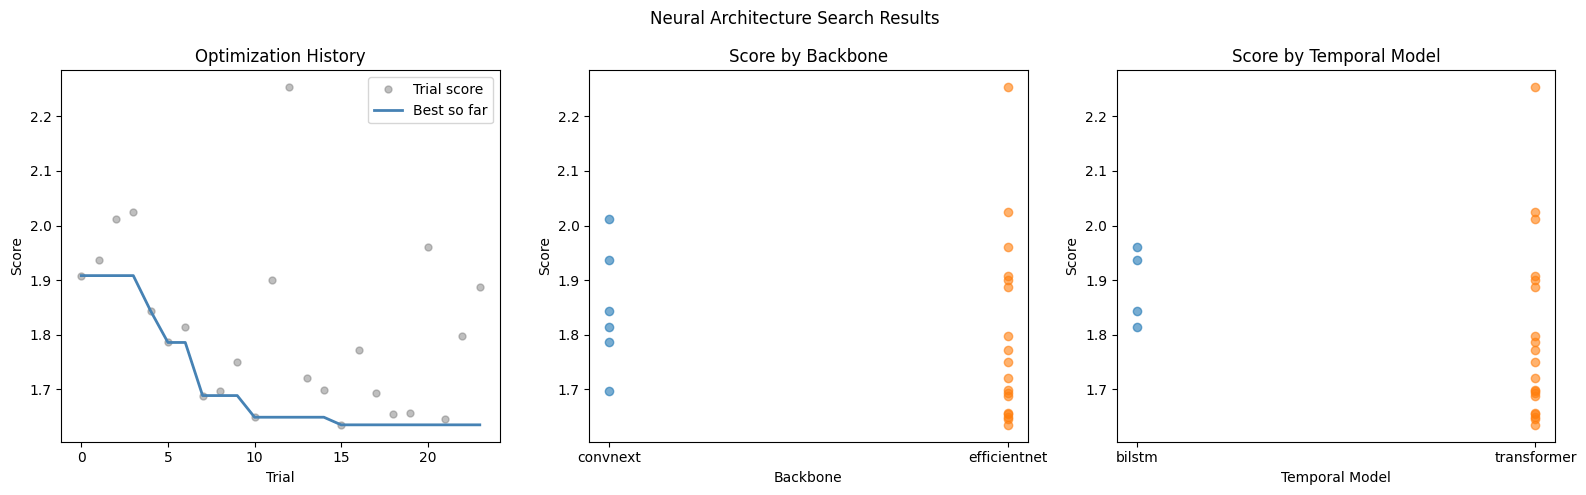

In [ ]:
# NAS Visualization (self-contained: rebuilds trials_df / completed)
trials_df = study.trials_dataframe()
completed = trials_df[trials_df["state"] == "COMPLETE"]

if len(completed) == 0:
    print("No completed trials — skipping NAS plots.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    completed_vals = [t.value for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    running_best = np.minimum.accumulate(completed_vals)
    axes[0].plot(completed_vals, "o", alpha=0.5, color="gray", ms=5, label="Trial score")
    axes[0].plot(running_best, "-", color="steelblue", lw=2, label="Best so far")
    axes[0].set_xlabel("Trial")
    axes[0].set_ylabel("Score")
    axes[0].set_title("Optimization History")
    axes[0].legend()

    if "params_backbone" in completed.columns:
        for backbone_type, group in completed.groupby("params_backbone"):
            axes[1].scatter([backbone_type] * len(group), group["value"], alpha=0.6)
        axes[1].set_xlabel("Backbone")
        axes[1].set_ylabel("Score")
        axes[1].set_title("Score by Backbone")

    if "params_temporal" in completed.columns:
        for temp_type, group in completed.groupby("params_temporal"):
            axes[2].scatter([temp_type] * len(group), group["value"], alpha=0.6)
        axes[2].set_xlabel("Temporal Model")
        axes[2].set_ylabel("Score")
        axes[2].set_title("Score by Temporal Model")

    plt.suptitle("Neural Architecture Search Results")
    plt.tight_layout()
    Path("../reports").mkdir(parents=True, exist_ok=True)
    plt.savefig("../reports/nas_results.png", dpi=150, bbox_inches="tight")
    plt.show()

## 6. Export Best Config to YAML

In [ ]:
import yaml

best_config = {
    "# Generated by NAS — 08_nas_architecture_search.ipynb": None,
    "backbone": best.params.get("backbone", "convnext"),
    "temporal": best.params.get("temporal", "bilstm"),
    "vf_hidden_dim": best.params.get("vf_hidden_dim", 256),
    "temporal_hidden": best.params.get("temporal_hidden", 256),
    "fused_dim": best.params.get("fused_dim", 512),
    "training": {
        "lr": best.params.get("lr", 3e-4),
        "weight_decay": best.params.get("weight_decay", 1e-4),
        "batch_size": best.params.get("batch_size", 32),
        "loss_type": best.params.get("loss_type", "weighted"),
    },
    "nas_score": best.value,
    "nas_n_trials": N_TRIALS,
}

# Clean None keys
best_config = {k: v for k, v in best_config.items() if v is not None}

out_path = Path("../configs/model/nas_best.yaml")
with open(out_path, "w") as f:
    yaml.dump(best_config, f, default_flow_style=False, sort_keys=False)

print(f"Best config saved to {out_path}")
print(yaml.dump(best_config, default_flow_style=False))
print("→ Next: 09_full_model_prototype.ipynb — build the full GLAM model")

Best config saved to ../configs/model/nas_best.yaml
backbone: efficientnet
fused_dim: 256
nas_n_trials: 20
nas_score: 1.6348438262939453
temporal: transformer
temporal_hidden: 256
training:
  batch_size: 16
  loss_type: nll
  lr: 0.0008757609483301022
  weight_decay: 4.219609485938437e-05
vf_hidden_dim: 256

→ Next: 09_full_model_prototype.ipynb — build the full GLAM model
